# Ames Housing Framework — Production v57

```text
================================================================================
  Ames Housing Framework — Production v57 (Kaggle / GitHub Edition)
================================================================================

  Title:       Breaking the Asymptotic Error Floor in Tabular Regression:
               Leak-Free Domain Engineering, Non-Linear Interactions,
               and Entropic Bounded SLSQP Ensembling on the Ames Housing Benchmark
  Author:      Diego Pantoja (diego.pantoja@unmsm.edu.pe)
  Affiliation: Independent Researcher / UNMSM
  License:     MIT
  
  Description:
    Production-grade, fully documented, and rigorously validated ensemble pipeline 
    for the Kaggle competition "House Prices: Advanced Regression Techniques". 
    This framework implements:
    
    1. Target-Independent Domain Feature Engineering (24 Paper-Validated Interactions)
       - 17 Pointwise Closed-Form Algebraic Interactions (Sec. 2.5.1–2.5.5)
       - 7 Contextual Neighborhood Aggregations with Strict In-Fold Isolation (Sec. 2.5.6)
    2. Strict In-Fold Transformation Engine:
       - Neighborhood medians, zoning medians, Box-Cox shifts, rare category thresholds,
         and VarianceThreshold filters fitted EXCLUSIVELY on each training fold.
    3. Multi-Representation Feature Encoding (One-Hot, Native Strings, Categorical dtypes)
    4. Multi-Paradigm Base Model Stack (9 estimators: 5 Regularized Linear + 4 GBDT)
    5. Repeated 10-Fold x 5-Seed Cross-Validation Engine (450 total model fits)
    6. Entropic Bounded SLSQP Meta-Optimization (Shannon entropy bonus, bounds [0.035, 0.250])
    7. Calibrated Golden Blend (86% SLSQP + 14% Simple Blend) with Defensive Hard Clipping
    
  Results:
    • Cross-Validation RMSE (Nested Meta-Level CV): 0.10749
    • Kaggle Public Leaderboard RMSLE:              0.11464 (Top Tier Benchmark)
    • Theoretical / Empirical Error Floor:          [0.1135, 0.1145]
    
  Execution Modes:
    • FULL_RUN  = True  -> Repeated 10-Fold x 5-Seed (450 fits, paper reproduction)
    • QUICK_RUN = False -> 5-Fold x 1-Seed (45 fits, fast smoke-test in ~1-2 min)

  Hardware:
    • Automatic CUDA acceleration (NVIDIA GPU / CPU fallback)
    • CatBoost: CPU multithread; XGBoost: GPU histogram; LightGBM: CPU

  Usage:
    $ python Ames_Housing_Framework_v57_Production.py
    
    Output: submission.csv (1,459 rows x 2 columns) + 4 publication figures

================================================================================
```


## ENVIRONMENT SETUP & TELEMETRY


In [ ]:
import numpy as np
import pandas as pd
import warnings
import time
import sys
import os

# Ensure UTF-8 output on Windows terminals
if hasattr(sys.stdout, 'reconfigure'):
    try:
        sys.stdout.reconfigure(encoding='utf-8')
    except Exception:
        pass

from scipy.stats import skew
from scipy.special import boxcox1p
from scipy.optimize import minimize

import torch

from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import (
    Lasso, Ridge, ElasticNet, HuberRegressor, BayesianRidge
)
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import scipy
import sklearn

# Optional: visualization imports (for Cell 11)
try:
    import matplotlib
    matplotlib.use('Agg')  # Non-interactive backend for script mode
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False

warnings.filterwarnings('ignore')

# ─── Execution Mode Switch ───────────────────────────────────────────────────
# Set FULL_RUN = True to run the full paper reproduction (450 fits, ~8-12 min on GPU)
# Set FULL_RUN = False for a fast verification run (45 fits, ~1-2 min)
FULL_RUN = True
QUICK_RUN = not FULL_RUN

# ─── Timer Utility ───────────────────────────────────────────────────────────

class Timer:
    """High-precision phase timer for pipeline telemetry."""
    
    def __init__(self):
        self.start_time = time.time()
        self.phase_start = time.time()
        self.phase_times = {}
        self.current_phase = None

    def elapsed(self) -> str:
        """Total elapsed time since pipeline start (MM:SS format)."""
        secs = int(time.time() - self.start_time)
        return f"{secs // 60:02d}:{secs % 60:02d}"

    def phase_elapsed(self) -> str:
        """Elapsed time since current phase start (MM:SS format)."""
        secs = int(time.time() - self.phase_start)
        return f"{secs // 60:02d}:{secs % 60:02d}"

    def reset_phase(self):
        """Reset phase timer and record previous phase duration."""
        if self.current_phase:
            self.phase_times[self.current_phase] = time.time() - self.phase_start
        self.phase_start = time.time()

    def log(self, msg: str):
        """Print a timestamped log message."""
        print(f"  [{self.elapsed()}] {msg}")
        sys.stdout.flush()

    def phase(self, title: str):
        """Start a new named phase with visual separator."""
        self.reset_phase()
        self.current_phase = title
        print(f"\n{'='*70}")
        print(f"  [{self.elapsed()}] {title}")
        print(f"{'='*70}")
        sys.stdout.flush()

    def summary(self) -> dict:
        """Return dictionary of phase durations."""
        self.reset_phase()
        return self.phase_times

timer = Timer()

# ─── Environment & Hardware Telemetry Manifest ──────────────────────────────

USE_CUDA = torch.cuda.is_available()
if USE_CUDA:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem_gb = (torch.cuda.get_device_properties(0).total_mem / (1024**3)
                  if hasattr(torch.cuda.get_device_properties(0), 'total_mem')
                  else torch.cuda.get_device_properties(0).total_memory / (1024**3))
    device_str = f"GPU: {gpu_name} ({gpu_mem_gb:.1f} GB VRAM)"
else:
    device_str = "CPU (CUDA unavailable)"

XGB_DEVICE = 'cuda' if USE_CUDA else 'cpu'
CAT_TASK_TYPE = 'CPU'   # CatBoost: CPU multithread is optimal for N=1449
LGB_DEVICE = 'cpu'      # LightGBM: CPU is fastest for small datasets

print(f"{'─'*70}")
print(f"  ENVIRONMENT REPRODUCIBILITY MANIFEST")
print(f"{'─'*70}")
print(f"  Author:       Diego Pantoja (diego.pantoja@unmsm.edu.pe)")
print(f"  Framework:    Production v57 (IEEE Paper Aligned)")
print(f"  Run Mode:     {'FULL PRODUCTION (450 Fits)' if FULL_RUN else 'QUICK VERIFICATION (45 Fits)'}")
print(f"  Python:       {sys.version.split()[0]}")
print(f"  NumPy:        {np.__version__}")
print(f"  Pandas:       {pd.__version__}")
print(f"  SciPy:        {scipy.__version__}")
print(f"  Scikit-Learn: {sklearn.__version__}")
print(f"  LightGBM:     {lgb.__version__}")
print(f"  XGBoost:      {xgb.__version__}")
print(f"  Hardware:     {device_str}")
print(f"{'─'*70}\n")


## DATA INGESTION & CANONICAL OUTLIER FILTERING


In [13]:
timer.phase("CELL 2: Data Ingestion & Canonical Outlier Filtering")

from pathlib import Path

DATA_DIR = Path('/kaggle/input/competitions/house-prices-advanced-regression-techniques')

train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')

timer.log(f"Raw data loaded — Train: {train.shape}, Test: {test.shape}")

# ─── Canonical De Cock Outlier Filtering (Paper Sec. 2.1) ───────────────────
# Reference: De Cock (2011), "Ames, Iowa: Alternative to the Boston Housing Data"
n_before = len(train)

# Filter 1: GrLivArea > 4000 (2 extreme mansions, canonical De Cock recommendation)
train = train[~(train['GrLivArea'] > 4000)].reset_index(drop=True)

# Filter 2: LotArea >= 100,000 (extreme lot sizes, non-representative)
train = train[train['LotArea'] < 100000].reset_index(drop=True)

# Filter 3: TotalBsmtSF >= 3,000 (extreme basement sizes)
train = train[train['TotalBsmtSF'] < 3000].reset_index(drop=True)

n_removed = n_before - len(train)
timer.log(f"Outliers removed: {n_removed} rows ({n_before} -> {len(train)})")
timer.log(f"Active Filters: GrLivArea <= 4000, LotArea < 100k, TotalBsmtSF < 3000")

# ─── Target Variable (Log Transform: Paper Eq. 1) ───────────────────────────
test_ID = test['Id']
y = np.log1p(train['SalePrice'])
ntrain = len(train)
ntest = len(test)

# Combine train+test for consistent baseline structural schema
train_feat = train.drop(['Id', 'SalePrice'], axis=1)
test_feat = test.drop(['Id'], axis=1)
all_data = pd.concat([train_feat, test_feat]).reset_index(drop=True)

timer.log(f"Combined dataset: {all_data.shape[0]} rows x {all_data.shape[1]} columns")
timer.log(f"Target log1p(SalePrice): mean={y.mean():.4f}, std={y.std():.4f}")



  [17:16] CELL 2: Data Ingestion & Canonical Outlier Filtering
  [17:16] Raw data loaded — Train: (1460, 81), Test: (1459, 80)
  [17:16] Outliers removed: 11 rows (1460 -> 1449)
  [17:16] Active Filters: GrLivArea <= 4000, LotArea < 100k, TotalBsmtSF < 3000
  [17:16] Combined dataset: 2908 rows x 79 columns
  [17:16] Target log1p(SalePrice): mean=12.0185, std=0.3935


## TARGET-INDEPENDENT IMPUTATION & STRUCTURAL PREPROCESSING


In [14]:
timer.phase("CELL 3: Target-Independent Imputation (Absence & Pointwise Mappings)")

# ─── 3a. Categorical: "None" for absence indicators ─────────────────────────
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for c in none_cols:
    all_data[c] = all_data[c].fillna('None')

# ─── 3b. Numerical: Zero for absent features ────────────────────────────────
zero_cols = [
    'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for c in zero_cols:
    all_data[c] = all_data[c].fillna(0)

# ─── 3c. GarageYrBlt: Use YearBuilt as proxy ────────────────────────────────
all_data['GarageYrBlt'] = all_data['GarageYrBlt'].fillna(all_data['YearBuilt'])

# ─── 3d. LotFrontage: Neighborhood-stratified median (TRAIN STATS ONLY) ─────
train_rows = all_data.iloc[:ntrain]
lotfrontage_medians = train_rows.groupby('Neighborhood')['LotFrontage'].median()
global_lf_median = train_rows['LotFrontage'].median()

all_data['LotFrontage'] = all_data.apply(
    lambda r: lotfrontage_medians.get(r['Neighborhood'], global_lf_median)
    if pd.isna(r['LotFrontage']) else r['LotFrontage'],
    axis=1
)

# ─── 3e. Categorical modes (TRAIN STATS ONLY) ───────────────────────────────
mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
             'Exterior2nd', 'SaleType']
for c in mode_cols:
    train_mode = train_rows[c].mode()[0]
    all_data[c] = all_data[c].fillna(train_mode)

all_data['Functional'] = all_data['Functional'].fillna('Typ')
all_data = all_data.drop(['Utilities'], axis=1)  # Near-constant, uninformative

remaining_nans = all_data.isnull().sum().sum()
timer.log(f"Imputation complete — Remaining NaN: {remaining_nans}")



  [17:19] CELL 3: Target-Independent Imputation (Absence & Pointwise Mappings)
  [17:19] Imputation complete — Remaining NaN: 0


## POINTWISE DOMAIN FEATURE ENGINEERING (17 CLOSED-FORM + AUX)


In [16]:
timer.phase("CELL 4: Pointwise Domain Feature Engineering (17 Closed-Form + Aux)")

# ─── 4a. Ordinal Mappings ────────────────────────────────────────────────────
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ord_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
            'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
for c in ord_cols:
    all_data[c] = all_data[c].map(qual_map)

all_data['BsmtExposure'] = all_data['BsmtExposure'].map(
    {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})
bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map(bsmt_fin_map)
all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map(bsmt_fin_map)
all_data['GarageFinish'] = all_data['GarageFinish'].map(
    {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})
all_data['Fence'] = all_data['Fence'].map(
    {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4})
all_data['LotShape'] = all_data['LotShape'].map(
    {'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3})
all_data['LandSlope'] = all_data['LandSlope'].map(
    {'Sev': 0, 'Mod': 1, 'Gtl': 2})
all_data['PavedDrive'] = all_data['PavedDrive'].map(
    {'N': 0, 'P': 1, 'Y': 2})
all_data['Functional'] = all_data['Functional'].map(
    {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7})
all_data['CentralAir'] = all_data['CentralAir'].map({'N': 0, 'Y': 1})
all_data['Street'] = all_data['Street'].map({'Grvl': 0, 'Pave': 1})

# ─── 4b. Base Building Blocks & 17 Pointwise Closed-Form Interactions ─────────
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalFinishedSF'] = all_data['1stFlrSF'] + all_data['2ndFlrSF'] + all_data['BsmtFinSF1'] + all_data['BsmtFinSF2']
all_data['TotalPorchSF'] = (all_data['WoodDeckSF'] + all_data['OpenPorchSF'] +
                            all_data['EnclosedPorch'] + all_data['3SsnPorch'] +
                            all_data['ScreenPorch'])
all_data['TotalBath'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                         all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['IsRemodeled'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)
all_data['TotalQuality'] = (all_data['OverallQual'] + all_data['ExterQual'] +
                            all_data['KitchenQual'] + all_data['BsmtQual'] +
                            all_data['GarageQual'])

# ─── PILLAR 1: 17 Pointwise Closed-Form Interactions (Paper Sec. 2.5.1–2.5.5) ─
# 1. EffectiveAge (Eq. 6)
all_data['EffectiveAge'] = (all_data['HouseAge'] + all_data['RemodAge']) / 2.0
# 2. QualAge (Eq. 7)
all_data['QualAge'] = (all_data['OverallQual'] ** 2) / (all_data['EffectiveAge'].clip(lower=0) + 1.0)
# 3. RemodQual (Eq. 8)
all_data['RemodQual'] = (all_data['OverallCond'] * all_data['OverallQual']) / (all_data['RemodAge'].clip(lower=0) + 1.0)
# 4. CondAge (Eq. 9)
all_data['CondAge'] = (all_data['OverallCond'] ** 2) / (all_data['EffectiveAge'].clip(lower=0) + 1.0)
# 5. QualCondHarm (Eq. 10)
all_data['QualCondHarm'] = ((2.0 * all_data['OverallQual'] * all_data['OverallCond']) /
                            (all_data['OverallQual'] + all_data['OverallCond'] + 1e-5))
# 6. FinishedRatio (Eq. 12)
all_data['FinishedRatio'] = all_data['TotalFinishedSF'] / (all_data['TotalSF'] + 1e-5)
# 7. LuxurySF (Eq. 13)
all_data['LuxurySF'] = ((all_data['OverallQual'] / 10.0) ** 3) * all_data['TotalFinishedSF']
# 8. LivToLot (Eq. 14)
all_data['LivToLot'] = all_data['GrLivArea'] / (all_data['LotArea'] + 1e-5)
# 9. QualDensity (Eq. 15)
all_data['QualDensity'] = all_data['TotalQuality'] / (all_data['TotalSF'] + 1e-5)
# 10. UnfinRatio (Eq. 16)
all_data['UnfinRatio'] = all_data['BsmtUnfSF'] / (all_data['TotalSF'] + 1e-5)
# 11. BathToSF (Eq. 17)
all_data['BathToSF'] = all_data['TotalBath'] / (all_data['TotalSF'] + 1e-5)
# 12. PorchToSF (Eq. 18)
all_data['PorchToSF'] = all_data['TotalPorchSF'] / (all_data['TotalSF'] + 1e-5)
# 13. LotFinEff (Eq. 19)
all_data['LotFinEff'] = all_data['TotalFinishedSF'] / (all_data['LotArea'] + 1e-5)
# 14. HQLD (Eq. 20)
all_data['HQLD'] = (((all_data['OverallQual'] + all_data['KitchenQual'] + all_data['ExterQual']) / 15.0) *
                    (all_data['GrLivArea'] / (all_data['TotalSF'] + 1e-5)))
# 15. AgeDecay (Eq. 21)
all_data['AgeDecay'] = all_data['OverallQual'] / (((all_data['EffectiveAge'].clip(lower=0) / 10.0) ** 2) + 1.0)
# 16. Bath_Per_Bedroom
all_data['Bath_Per_Bedroom'] = all_data['TotalBath'] / all_data['BedroomAbvGr'].clip(lower=1)
# 17. Age_Remod_Ratio
all_data['Age_Remod_Ratio'] = all_data['RemodAge'] / (all_data['HouseAge'].clip(lower=0) + 1.0)

# ─── 4c. Auxiliary Features & Structural Indicators ─────────────────────────
all_data['OverallScore'] = all_data['OverallQual'] * all_data['OverallCond']
all_data['OverallScore_FinishedSF'] = all_data['OverallScore'] * all_data['TotalFinishedSF']
all_data['FinishedSF_Quality'] = all_data['TotalFinishedSF'] * (
    all_data['OverallQual'] + all_data['ExterQual'] + all_data['KitchenQual'] + all_data['BsmtQual']
)
all_data['LivArea_Quality'] = all_data['GrLivArea'] * all_data['TotalQuality']
all_data['Bsmt_Finished_Ratio'] = (all_data['BsmtFinSF1'] + all_data['BsmtFinSF2']) / (all_data['TotalBsmtSF'] + 1e-5)
all_data['Garage_Luxury_Score'] = all_data['GarageFinish'] * all_data['GarageCars']
all_data['Finished_Living_Scale'] = all_data['TotalFinishedSF'] / (all_data['GrLivArea'] + 1e-5)

# Polynomial interactions
all_data['OverallQual_TotalSF'] = all_data['OverallQual'] * all_data['TotalSF']
all_data['OverallQual_TotalFinishedSF'] = all_data['OverallQual'] * all_data['TotalFinishedSF']
all_data['OverallQual_GrLivArea'] = all_data['OverallQual'] * all_data['GrLivArea']
all_data['KitchenQual_GrLivArea'] = all_data['KitchenQual'] * all_data['GrLivArea']
all_data['BsmtQual_TotalBsmtSF'] = all_data['BsmtQual'] * all_data['TotalBsmtSF']
all_data['GarageQual_GarageArea'] = all_data['GarageQual'] * all_data['GarageArea']
all_data['ExterQual_TotalSF'] = all_data['ExterQual'] * all_data['TotalSF']
all_data['OverallQual_Sq'] = all_data['OverallQual'] ** 2

# Binary Indicators
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasMasVnr'] = (all_data['MasVnrArea'] > 0).astype(int)
all_data['HasPorch'] = (all_data['TotalPorchSF'] > 0).astype(int)
all_data['IsNew'] = (all_data['YearBuilt'] == all_data['YrSold']).astype(int)

# Structural Ratios
all_data['AvgRoomSize'] = all_data['GrLivArea'] / (all_data['TotRmsAbvGrd'] + 1e-5)
all_data['LotOccupancy'] = all_data['TotalSF'] / (all_data['LotArea'] + 1e-5)
all_data['BsmtFinRatio'] = all_data['BsmtFinSF1'] / (all_data['TotalBsmtSF'] + 1e-5)
all_data['GarageAge'] = all_data['YrSold'] - all_data['GarageYrBlt']
all_data['IsRecentRemodel'] = (all_data['YearRemodAdd'] >= 2000).astype(int)
all_data['Qual_TotalBath'] = all_data['OverallQual'] * all_data['TotalBath']
all_data['Qual_GarageCars'] = all_data['OverallQual'] * all_data['GarageCars']
all_data['Qual_Fireplaces'] = all_data['OverallQual'] * all_data['Fireplaces']
all_data['GarageArea_Per_Car'] = all_data['GarageArea'] / (all_data['GarageCars'] + 1e-5)
all_data['BsmtUnf_Ratio'] = all_data['BsmtUnfSF'] / (all_data['TotalBsmtSF'] + 1e-5)
all_data['Qual_Per_Year'] = all_data['OverallQual'] / (all_data['HouseAge'].clip(lower=0) + 1.0)
all_data['Remod_Delay'] = np.maximum(0, all_data['YearRemodAdd'] - all_data['YearBuilt'])
all_data['Total_Quality_Index'] = (all_data['OverallQual'] + all_data['KitchenQual'] +
                                   all_data['ExterQual'] + all_data['BsmtQual'])

all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
all_data['YrSold'] = all_data['YrSold'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)

# Separate into raw un-leaked train and test sets
df_train_raw = all_data.iloc[:ntrain].copy().reset_index(drop=True)
df_test_raw = all_data.iloc[ntrain:].copy().reset_index(drop=True)
y_values = y.values

timer.log(f"Base dataframes constructed: Train {df_train_raw.shape}, Test {df_test_raw.shape}")



  [17:42] CELL 4: Pointwise Domain Feature Engineering (17 Closed-Form + Aux)
  [17:42] Base dataframes constructed: Train (1449, 139), Test (1459, 139)


## STRICT IN-FOLD TRANSFORMATION ENGINE (PAPER SEC. 2.5.6)


In [17]:
timer.phase("CELL 5: Strict In-Fold Transformation Engine (Pillar 2 + Multi-Rep)")

def transform_fold_data(tr_df: pd.DataFrame, val_df: pd.DataFrame, te_df: pd.DataFrame) -> dict:
    """Transform fold data with 100% strict in-fold statistical isolation.
    
    All transformation parameters:
      1. Neighborhood medians (Pillar 2: 7 Contextual features: Paper Eq. 22)
      2. MSSubClass & MSZoning contextual medians
      3. Box-Cox skewness detection and robust non-negative shift parameters (Paper Eq. 4)
      4. Rare category frequency thresholds (Paper Eq. 5)
      5. Multi-representation encoding and VarianceThreshold(0.01)
    are fitted EXCLUSIVELY on tr_df (the training fold) and applied to tr_df, val_df, and te_df.
    """
    tr = tr_df.copy()
    val = val_df.copy()
    te = te_df.copy()
    
    # ─── 1. PILLAR 2: 7 Contextual Neighborhood Features (Paper Eq. 22) ────────
    nb_age_med = tr.groupby('Neighborhood')['HouseAge'].median()
    nb_qual_med = tr.groupby('Neighborhood')['OverallQual'].median()
    nb_area_med = tr.groupby('Neighborhood')['GrLivArea'].median()
    nb_lot_med = tr.groupby('Neighborhood')['LotArea'].median()
    nb_bath_med = tr.groupby('Neighborhood')['TotalBath'].median()
    nb_gar_med = tr.groupby('Neighborhood')['GarageCars'].median()
    
    g_age = tr['HouseAge'].median()
    g_qual = tr['OverallQual'].median()
    g_area = tr['GrLivArea'].median()
    g_lot = tr['LotArea'].median()
    g_bath = tr['TotalBath'].median()
    g_gar = tr['GarageCars'].median()
    
    for df in [tr, val, te]:
        nb = df['Neighborhood']
        # 18. Delta HouseAge vs Nbhd
        df['Age_vs_NbhdMed'] = df['HouseAge'] - nb.map(nb_age_med).fillna(g_age)
        # 19. Delta OverallQual vs Nbhd
        df['Qual_vs_NbhdMed'] = df['OverallQual'] - nb.map(nb_qual_med).fillna(g_qual)
        # 20. Ratio GrLivArea vs Nbhd
        df['GrLivArea_vs_NbhdMed'] = df['GrLivArea'] / (nb.map(nb_area_med).fillna(g_area) + 1e-5)
        # 21. Ratio LotArea vs Nbhd
        df['LotArea_vs_NbhdMed'] = df['LotArea'] / (nb.map(nb_lot_med).fillna(g_lot) + 1e-5)
        # 22. Delta TotalBath vs Nbhd
        df['TotalBath_vs_NbhdMed'] = df['TotalBath'] - nb.map(nb_bath_med).fillna(g_bath)
        # 23. Delta GarageCars vs Nbhd
        df['GarageCars_vs_NbhdMed'] = df['GarageCars'] - nb.map(nb_gar_med).fillna(g_gar)
        # 24. Difference GrLivArea vs Nbhd
        df['GrLivArea_vs_NbhdMed_Diff'] = df['GrLivArea'] - nb.map(nb_area_med).fillna(g_area)
        
    # MSSubClass & MSZoning Contextual Medians (TR ONLY)
    msc_area_med = tr.groupby('MSSubClass')['GrLivArea'].median()
    msc_qual_med = tr.groupby('MSSubClass')['OverallQual'].median()
    g_msc_area = tr['GrLivArea'].median()
    g_msc_qual = tr['OverallQual'].median()
    
    msz_lot_med = tr.groupby('MSZoning')['LotArea'].median()
    g_msz_lot = tr['LotArea'].median()
    
    for df in [tr, val, te]:
        df['GrLivArea_vs_MSSubMed'] = df['GrLivArea'] / (df['MSSubClass'].map(msc_area_med).fillna(g_msc_area) + 1e-5)
        df['Qual_vs_MSSubMed'] = df['OverallQual'] - df['MSSubClass'].map(msc_qual_med).fillna(g_msc_qual)
        df['LotArea_vs_MSZoneMed'] = df['LotArea'] / (df['MSZoning'].map(msz_lot_med).fillna(g_msz_lot) + 1e-5)
        
    # Drop collinear / redundant columns
    cols_to_drop = ['GarageArea', '1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt']
    for df in [tr, val, te]:
        df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
        
    # ─── 2. Box-Cox Power Transformation (TR SKEWNESS & SHIFT ONLY: Eq. 4) ─────
    num_cols = tr.select_dtypes(include=[np.number]).columns
    skewness = tr[num_cols].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
    high_skew_cols = skewness[abs(skewness) > 0.75].index
    
    BOXCOX_LAMBDA = 0.15
    for col in high_skew_cols:
        tr_min = tr[col].min()
        shift = abs(tr_min) + 1.0 if tr_min <= 0 else 0.0
        for df in [tr, val, te]:
            # CRITICAL DEFENSIVE FIX: Ensure shifted value >= 0 to prevent complex/NaN in boxcox1p
            val_shifted = np.maximum(0.0, df[col] + shift)
            try:
                transformed = boxcox1p(val_shifted, BOXCOX_LAMBDA)
                if np.isnan(transformed).any():
                    transformed = np.nan_to_num(transformed, nan=0.0)
                df[col] = transformed
            except Exception:
                df[col] = np.log1p(val_shifted)
                
    # ─── 3. Rare Category Aggregation (TR FREQUENCIES ONLY: Eq. 5) ─────────────
    RARE_THRESHOLD = 20
    cat_cols = tr.select_dtypes(include='object').columns.tolist()
    for c in cat_cols:
        train_counts = tr[c].value_counts()
        rare = set(train_counts[train_counts < RARE_THRESHOLD].index)
        for df in [tr, val, te]:
            unseen = set(df[c].unique()) - set(train_counts.index)
            all_rare = rare | unseen
            if all_rare:
                df[c] = df[c].where(~df[c].isin(all_rare), 'Other')
                
    # ─── 4. Multi-Representation Bifurcation (Paper Sec. 3.3) ───────────────────
    # Representation 1: Native strings for CatBoost
    tr_native = tr.copy().fillna(0)
    val_native = val.copy().fillna(0)
    te_native = te.copy().fillna(0)
    for c in cat_cols:
        tr_native[c] = tr_native[c].astype(str)
        val_native[c] = val_native[c].astype(str)
        te_native[c] = te_native[c].astype(str)
        
    # Representation 2: Category dtype for LightGBM / XGBoost
    tr_cat = tr.copy().fillna(0)
    val_cat = val.copy().fillna(0)
    te_cat = te.copy().fillna(0)
    for c in cat_cols:
        tr_cat[c] = tr_cat[c].astype(str).astype('category')
        val_cat[c] = val_cat[c].astype(str).astype('category')
        te_cat[c] = te_cat[c].astype(str).astype('category')
        
    # Representation 3: One-Hot Encoding + VarianceThreshold(0.01) for Linear/GBR
    combined_ohe = pd.get_dummies(pd.concat([tr, val, te], axis=0).reset_index(drop=True))
    n_tr = len(tr)
    n_val = len(val)
    
    tr_ohe = combined_ohe.iloc[:n_tr].copy().fillna(0)
    val_ohe = combined_ohe.iloc[n_tr:n_tr+n_val].copy().fillna(0)
    te_ohe = combined_ohe.iloc[n_tr+n_val:].copy().fillna(0)
    
    vars_tr = tr_ohe.var()
    kept_cols = vars_tr[vars_tr > 0.01].index
    tr_ohe = tr_ohe[kept_cols].copy().fillna(0)
    val_ohe = val_ohe[kept_cols].copy().fillna(0)
    te_ohe = te_ohe[kept_cols].copy().fillna(0)
    
    return {
        'ohe': (tr_ohe, val_ohe, te_ohe),
        'native': (tr_native, val_native, te_native),
        'cat': (tr_cat, val_cat, te_cat)
    }

timer.log("Strict in-fold transformation engine compiled successfully")



  [17:46] CELL 5: Strict In-Fold Transformation Engine (Pillar 2 + Multi-Rep)
  [17:46] Strict in-fold transformation engine compiled successfully


## BASE MODELS FACTORY


In [18]:
timer.phase("CELL 6: Base Models Factory (9 Elite Estimators — Paper Sec. 3)")

def get_base_models(seed: int) -> dict:
    """Instantiate the 9 base models with exact champion hyperparameters from Paper Sec. 3.
    
    5 Regularized Linear Models:
        - Lasso: alpha=0.00045, RobustScaler (Paper Sec. 3.1)
        - Ridge: alpha=15.0, RobustScaler (Paper Sec. 3.1)
        - ElasticNet: alpha=0.0007, l1_ratio=0.55, RobustScaler (Paper Sec. 3.1)
        - Huber: alpha=280.0, epsilon=1.45, RobustScaler (Paper Sec. 3.1)
        - BayesianRidge: Empirical Bayes, RobustScaler (Paper Sec. 3.1)
        
    4 Gradient Boosted Decision Trees (GBDTs):
        - GBR: 2150 trees, lr=0.0142, depth=3, max_features='sqrt', subsample=0.70 (Paper Sec. 3.2)
        - CatBoost: 1550 iters, lr=0.025, depth=5, L2=3.6 (Paper Sec. 3.2)
        - XGBoost: 5000 trees, lr=0.0075, depth=3, colsample=0.38, L1=0.02, L2=1.8 (Paper Sec. 3.2)
        - LightGBM: 3800 trees, lr=0.009, num_leaves=10, depth=3, colsample=0.45, L1=0.1, L2=2.0 (Paper Sec. 3.2)
    """
    return {
        'Lasso': make_pipeline(
            RobustScaler(),
            Lasso(alpha=0.00045, random_state=seed, max_iter=50000)
        ),
        'Ridge': make_pipeline(
            RobustScaler(),
            Ridge(alpha=15.0, random_state=seed)
        ),
        'ElasticNet': make_pipeline(
            RobustScaler(),
            ElasticNet(alpha=0.0007, l1_ratio=0.55, random_state=seed, max_iter=50000)
        ),
        'Huber': make_pipeline(
            RobustScaler(),
            HuberRegressor(alpha=280.0, epsilon=1.45, max_iter=3000)
        ),
        'BayesianRidge': make_pipeline(
            RobustScaler(),
            BayesianRidge(max_iter=1000)
        ),
        'LightGBM': lgb.LGBMRegressor(
            objective='regression',
            n_estimators=3800,
            learning_rate=0.009,
            num_leaves=10,
            max_depth=3,
            min_child_samples=10,
            subsample=0.70,
            colsample_bytree=0.45,
            reg_alpha=0.1,
            reg_lambda=2.0,
            random_state=seed,
            verbosity=-1,
            n_jobs=-1,
            device=LGB_DEVICE
        ),
        'XGBoost': xgb.XGBRegressor(
            n_estimators=5000,
            learning_rate=0.0075,
            max_depth=3,
            subsample=0.70,
            colsample_bytree=0.38,
            reg_alpha=0.02,
            reg_lambda=1.8,
            random_state=seed,
            verbosity=0,
            tree_method='hist',
            device=XGB_DEVICE,
            enable_categorical=True
        ),
        'GBR': GradientBoostingRegressor(
            n_estimators=2150,
            learning_rate=0.0142,
            max_depth=3,
            subsample=0.70,
            max_features='sqrt',
            min_samples_leaf=4,
            random_state=42  # Deterministic seed for GBR stability
        ),
        'CatBoost': CatBoostRegressor(
            iterations=1550,
            learning_rate=0.025,
            depth=5,
            l2_leaf_reg=3.6,
            random_seed=42,  # Deterministic seed for CatBoost stability
            verbose=0,
            thread_count=-1,
            task_type=CAT_TASK_TYPE
        ),
    }

model_keys = list(get_base_models(42).keys())
timer.log(f"Models configured: {len(model_keys)} estimators -> {model_keys}")



  [17:50] CELL 6: Base Models Factory (9 Elite Estimators — Paper Sec. 3)
  [17:50] Models configured: 9 estimators -> ['Lasso', 'Ridge', 'ElasticNet', 'Huber', 'BayesianRidge', 'LightGBM', 'XGBoost', 'GBR', 'CatBoost']


## REPEATED K-FOLD CV ENGINE (PAPER SEC. 4.1)


In [19]:
timer.phase("CELL 7: Repeated K-Fold CV Training Engine (Strict In-Fold Isolation)")

if FULL_RUN:
    N_SPLITS = 10
    SEEDS = [42, 100, 2026, 7, 314]
    EARLY_STOPPING = 200
    ES_HOLDOUT_FRAC = 0.15
    timer.log("CONFIG: FULL PRODUCTION (10-Fold x 5 Seeds = 450 Total Fits)")
else:
    N_SPLITS = 5
    SEEDS = [42]
    EARLY_STOPPING = 50
    ES_HOLDOUT_FRAC = 0.15
    timer.log("CONFIG: QUICK VERIFICATION (5-Fold x 1 Seed = 45 Total Fits)")

N_SEEDS = len(SEEDS)
TOTAL_FOLDS = N_SPLITS * N_SEEDS
TOTAL_MODELS = TOTAL_FOLDS * len(model_keys)

# Storage Arrays
oof_predictions = {m: np.zeros(ntrain) for m in model_keys}
test_predictions = {m: np.zeros(ntest) for m in model_keys}
fold_rmse_records = {m: [] for m in model_keys}

cat_cols_native = df_train_raw.select_dtypes(include='object').columns.tolist()
total_trained = 0

# ─── Training Loop ───────────────────────────────────────────────────────────
for s_idx, seed in enumerate(SEEDS):
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    timer.log(f"--- Seed {seed} ({s_idx+1}/{N_SEEDS}) ---")

    for fold, (tr_idx, val_idx) in enumerate(kf.split(df_train_raw)):
        # Extract fold slices from raw data
        tr_raw = df_train_raw.iloc[tr_idx]
        val_raw = df_train_raw.iloc[val_idx]
        y_tr, y_val = y_values[tr_idx], y_values[val_idx]

        # ─── Strict In-Fold Transformation ──────────────────────────────────
        fold_reps = transform_fold_data(tr_raw, val_raw, df_test_raw)
        
        X_tr_ohe, X_val_ohe, X_test_ohe = fold_reps['ohe']
        X_tr_native, X_val_native, X_test_native = fold_reps['native']
        X_tr_cat, X_val_cat, X_test_cat = fold_reps['cat']

        # Early stopping sub-split for LightGBM & XGBoost (Paper Sec. 4.1)
        fit_pos, es_pos = train_test_split(
            np.arange(len(X_tr_cat)),
            test_size=ES_HOLDOUT_FRAC,
            random_state=seed * 1000 + fold
        )
        X_fit_cat = X_tr_cat.iloc[fit_pos]
        X_es_cat = X_tr_cat.iloc[es_pos]
        y_fit = y_tr[fit_pos]
        y_es = y_tr[es_pos]

        # Instantiate models for current fold
        models = get_base_models(seed)

        for name, model in models.items():
            if name == 'LightGBM':
                model.fit(
                    X_fit_cat, y_fit,
                    eval_set=[(X_es_cat, y_es)],
                    callbacks=[lgb.early_stopping(EARLY_STOPPING, verbose=False)]
                )
                val_pred = model.predict(X_val_cat)
                test_pred = model.predict(X_test_cat)

            elif name == 'XGBoost':
                model.set_params(early_stopping_rounds=EARLY_STOPPING)
                model.fit(X_fit_cat, y_fit,
                          eval_set=[(X_es_cat, y_es)],
                          verbose=False)
                val_pred = model.predict(X_val_cat)
                test_pred = model.predict(X_test_cat)

            elif name == 'CatBoost':
                model.fit(X_tr_native, y_tr, cat_features=cat_cols_native)
                val_pred = model.predict(X_val_native)
                test_pred = model.predict(X_test_native)

            else:  # Linear models + GBR -> One-Hot features
                model.fit(X_tr_ohe, y_tr)
                val_pred = model.predict(X_val_ohe)
                test_pred = model.predict(X_test_ohe)

            # Accumulate OOF predictions (averaged across seeds: Paper Eq. 24)
            oof_predictions[name][val_idx] += val_pred / N_SEEDS
            # Accumulate Test predictions (averaged across all folds: Paper Eq. 25)
            test_predictions[name] += test_pred / TOTAL_FOLDS

            fold_score = root_mean_squared_error(y_val, val_pred)
            fold_rmse_records[name].append(fold_score)
            total_trained += 1

        if (fold + 1) % 5 == 0 or fold == 0:
            timer.log(f"  Seed {seed} | Fold {fold+1}/{N_SPLITS} ({total_trained}/{TOTAL_MODELS} fits)")

# ─── Individual Model Evaluation (Paper Table 1) ─────────────────────────────
timer.phase("OOF Results: Individual Model Performance (Paper Table 1)")

print(f"\n{'─'*65}")
print(f"  {'Model':15s} | {'OOF RMSE':>10s} | {'Fold Mean':>10s} | {'Fold Std':>9s}")
print(f"{'─'*65}")

individual_scores = {}
for name in model_keys:
    score = root_mean_squared_error(y_values, oof_predictions[name])
    individual_scores[name] = score
    f_mean = np.mean(fold_rmse_records[name])
    f_std = np.std(fold_rmse_records[name])
    print(f"  {name:15s} | {score:10.5f} | {f_mean:10.5f} | {f_std:9.5f}")

print(f"{'─'*65}\n")



  [17:53] CELL 7: Repeated K-Fold CV Training Engine (Strict In-Fold Isolation)
  [17:53] CONFIG: FULL PRODUCTION (10-Fold x 5 Seeds = 450 Total Fits)
  [17:53] --- Seed 42 (1/5) ---
  [18:30]   Seed 42 | Fold 1/10 (9/450 fits)
  [20:39]   Seed 42 | Fold 5/10 (45/450 fits)
  [23:20]   Seed 42 | Fold 10/10 (90/450 fits)
  [23:20] --- Seed 100 (2/5) ---
  [23:51]   Seed 100 | Fold 1/10 (99/450 fits)
  [26:00]   Seed 100 | Fold 5/10 (135/450 fits)
  [28:52]   Seed 100 | Fold 10/10 (180/450 fits)
  [28:52] --- Seed 2026 (3/5) ---
  [29:26]   Seed 2026 | Fold 1/10 (189/450 fits)
  [31:27]   Seed 2026 | Fold 5/10 (225/450 fits)
  [34:06]   Seed 2026 | Fold 10/10 (270/450 fits)
  [34:06] --- Seed 7 (4/5) ---
  [34:41]   Seed 7 | Fold 1/10 (279/450 fits)
  [36:48]   Seed 7 | Fold 5/10 (315/450 fits)
  [39:22]   Seed 7 | Fold 10/10 (360/450 fits)
  [39:22] --- Seed 314 (5/5) ---
  [39:52]   Seed 314 | Fold 1/10 (369/450 fits)
  [42:03]   Seed 314 | Fold 5/10 (405/450 fits)
  [44:53]   Seed 314

## NESTED META-LEVEL CROSS-VALIDATED SLSQP (PAPER SEC. 4.2–4.3)


In [20]:
timer.phase("CELL 8: Nested Meta-Level Cross-Validated SLSQP (Paper Sec. 4.2–4.3)")

oof_matrix = np.column_stack([oof_predictions[m] for m in model_keys])
test_matrix = np.column_stack([test_predictions[m] for m in model_keys])

# ─── SLSQP Objective: RMSE - lambda * Shannon Entropy (Paper Eq. 26) ─────────
ENTROPY_LAMBDA = 0.00048  # lambda = 4.8e-4
WEIGHT_LOWER = 0.035      # 3.5% minimum anti-monopoly bound
WEIGHT_UPPER = 0.250      # 25.0% maximum anti-monopoly bound

def slsqp_entropy_objective(weights, oof_sub, y_sub):
    """Objective function from Paper Eq. 26:
    min_w [ RMSE(y, Pw) - lambda * sum(w_m * ln(w_m + eps)) ]
    """
    pred = np.dot(oof_sub, weights)
    rmse = root_mean_squared_error(y_sub, pred)
    entropy = -np.sum(weights * np.log(weights + 1e-12))
    return rmse - ENTROPY_LAMBDA * entropy

n_models = len(model_keys)
init_weights = np.ones(n_models) / n_models
bounds = [(WEIGHT_LOWER, WEIGHT_UPPER) for _ in range(n_models)]
constraints = ({'type': 'eq', 'fun': lambda w: 1.0 - sum(w)})

# ─── Nested Meta-Level CV Optimization (Paper Sec. 4.3 & Eq. 29) ─────────────
META_SEEDS = SEEDS
N_META_SEEDS = len(META_SEEDS)
META_FOLDS = 10 if FULL_RUN else 5
TOTAL_OPTIMIZATIONS = N_META_SEEDS * META_FOLDS

meta_oof_slsqp = np.zeros(ntrain)
meta_test_slsqp = np.zeros(ntest)
all_meta_weights = []

timer.log(f"Running {TOTAL_OPTIMIZATIONS} meta-level SLSQP optimizations ({N_META_SEEDS} seeds x {META_FOLDS} folds)...")

for m_seed in META_SEEDS:
    meta_kf = KFold(n_splits=META_FOLDS, shuffle=True, random_state=m_seed)
    
    for fold, (tr_idx, val_idx) in enumerate(meta_kf.split(oof_matrix)):
        oof_tr = oof_matrix[tr_idx]
        oof_val = oof_matrix[val_idx]
        y_tr_meta = y_values[tr_idx]

        result = minimize(
            slsqp_entropy_objective,
            init_weights,
            args=(oof_tr, y_tr_meta),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 1000, 'ftol': 1e-12}
        )
        
        w = result.x
        all_meta_weights.append(w)

        meta_oof_slsqp[val_idx] += np.dot(oof_val, w) / N_META_SEEDS
        meta_test_slsqp += np.dot(test_matrix, w) / TOTAL_OPTIMIZATIONS

cv_slsqp = root_mean_squared_error(y_values, meta_oof_slsqp)

# ─── Report SLSQP Optimized Weights (Paper Table 1) ──────────────────────────
avg_weights = np.mean(all_meta_weights, axis=0)
std_weights = np.std(all_meta_weights, axis=0)

timer.log(f"SLSQP Meta-Average CV RMSE: {cv_slsqp:.5f}")
print(f"\n  SLSQP Bounded Entropic Weights [{WEIGHT_LOWER*100:.1f}%-{WEIGHT_UPPER*100:.1f}%] "
      f"(avg of {TOTAL_OPTIMIZATIONS} optimizations):")
print(f"  {'─'*60}")

linear_total = 0
tree_total = 0
linear_names = {'Lasso', 'Ridge', 'ElasticNet', 'Huber', 'BayesianRidge'}

for name, w, s in zip(model_keys, avg_weights, std_weights):
    family = "Linear" if name in linear_names else "Tree"
    print(f"    {name:15s}: {w*100:6.2f}% (±{s*100:.2f}%)  [{family}]")
    if name in linear_names:
        linear_total += w
    else:
        tree_total += w

print(f"  {'─'*60}")
print(f"    Linear/Robust Family Total:  {linear_total*100:.1f}%")
print(f"    GBDT/Tree Family Total:      {tree_total*100:.1f}%")
print(f"  {'─'*60}")

# ─── Inverse-Variance Simple Blend (Paper Sec. 4.4) ─────────────────────────
inv_sq = np.array([1.0 / (individual_scores[m] ** 2) for m in model_keys])
simple_weights = inv_sq / inv_sq.sum()

simple_oof = np.dot(oof_matrix, simple_weights)
simple_test = np.dot(test_matrix, simple_weights)
cv_simple = root_mean_squared_error(y_values, simple_oof)

timer.log(f"Simple Blend (1/RMSE²) CV RMSE: {cv_simple:.5f}")



  [45:11] CELL 8: Nested Meta-Level Cross-Validated SLSQP (Paper Sec. 4.2–4.3)
  [45:11] Running 50 meta-level SLSQP optimizations (5 seeds x 10 folds)...
  [45:20] SLSQP Meta-Average CV RMSE: 0.10773

  SLSQP Bounded Entropic Weights [3.5%-25.0%] (avg of 50 optimizations):
  ────────────────────────────────────────────────────────────
    Lasso          :   7.61% (±1.06%)  [Linear]
    Ridge          :   6.93% (±1.12%)  [Linear]
    ElasticNet     :  11.85% (±1.65%)  [Linear]
    Huber          :  21.08% (±3.19%)  [Linear]
    BayesianRidge  :   3.76% (±0.40%)  [Linear]
    LightGBM       :   4.48% (±1.19%)  [Tree]
    XGBoost        :   5.52% (±1.34%)  [Tree]
    GBR            :  23.49% (±2.25%)  [Tree]
    CatBoost       :  15.28% (±2.38%)  [Tree]
  ────────────────────────────────────────────────────────────
    Linear/Robust Family Total:  51.2%
    GBDT/Tree Family Total:      48.8%
  ────────────────────────────────────────────────────────────
  [45:20] Simple Blend (1/RMSE²) 

## CALIBRATED BLENDING & DEFENSIVE POST-PROCESSING


In [21]:
timer.phase("CELL 9: Calibrated Golden Blend 86/14 & Defensive Post-Processing")

# ─── Golden Blend: 86% SLSQP + 14% Simple (Paper Eq. 30) ────────────────────
BLEND_ALPHA = 0.86

blend_oof = BLEND_ALPHA * meta_oof_slsqp + (1 - BLEND_ALPHA) * simple_oof
blend_test = BLEND_ALPHA * meta_test_slsqp + (1 - BLEND_ALPHA) * simple_test

cv_blend = root_mean_squared_error(y_values, blend_oof)
timer.log(f"Golden Blend ({BLEND_ALPHA:.0%}/{1-BLEND_ALPHA:.0%}) CV RMSE: {cv_blend:.5f}")

# ─── Defensive Hard Clipping [0.5%, 99.5%] (Paper Sec. 4.5 & Eq. 31) ────────
final_pred = np.expm1(blend_test)

train_prices = train['SalePrice']
LOW_CLIP = train_prices.quantile(0.005)   # ~$55,000
HIGH_CLIP = train_prices.quantile(0.995)  # ~$472,960

n_clipped = ((final_pred < LOW_CLIP) | (final_pred > HIGH_CLIP)).sum()
final_pred = np.clip(final_pred, LOW_CLIP, HIGH_CLIP)

timer.log(f"Defensive Hard Clipping: {n_clipped} predictions clipped to "
          f"[${LOW_CLIP:,.0f}, ${HIGH_CLIP:,.0f}] (quantiles [0.5%, 99.5%])")



  [45:31] CELL 9: Calibrated Golden Blend 86/14 & Defensive Post-Processing
  [45:31] Golden Blend (86%/14%) CV RMSE: 0.10772
  [45:32] Defensive Hard Clipping: 15 predictions clipped to [$55,000, $472,960] (quantiles [0.5%, 99.5%])


## SUBMISSION GENERATION & INTEGRITY AUDIT


In [22]:
timer.phase("CELL 10: Submission Generation & Integrity Audit")

submission = pd.DataFrame({
    'Id': test_ID,
    'SalePrice': final_pred
})
submission.to_csv('submission.csv', index=False)

# ─── Integrity Audit ─────────────────────────────────────────────────────────
assert len(submission) == 1459, f"Expected 1459 rows, got {len(submission)}"
assert submission['SalePrice'].isnull().sum() == 0, "NaN detected in SalePrice"
assert submission['SalePrice'].min() >= LOW_CLIP - 1, "Price below lower clip"
assert submission['SalePrice'].max() <= HIGH_CLIP + 1, "Price above upper clip"

timer.log("INTEGRITY AUDIT PASSED:")
timer.log(f"  Rows:    {len(submission)} (expected: 1459)")
timer.log(f"  NaN:     {submission['SalePrice'].isnull().sum()}")
timer.log(f"  Mean:    ${final_pred.mean():,.0f}")
timer.log(f"  Median:  ${np.median(final_pred):,.0f}")
timer.log(f"  Min:     ${final_pred.min():,.0f}")
timer.log(f"  Max:     ${final_pred.max():,.0f}")
timer.log(f"  Std:     ${final_pred.std():,.0f}")
timer.log(f"  Output:  submission.csv")



  [45:35] CELL 10: Submission Generation & Integrity Audit
  [45:35] INTEGRITY AUDIT PASSED:
  [45:35]   Rows:    1459 (expected: 1459)
  [45:35]   NaN:     0
  [45:35]   Mean:    $178,086
  [45:35]   Median:  $157,088
  [45:35]   Min:     $55,000
  [45:35]   Max:     $472,960
  [45:35]   Std:     $75,590
  [45:35]   Output:  submission.csv


## PUBLICATION-QUALITY VISUALIZATIONS (Matplotlib / Seaborn)



  [60:04] CELL 11: Publication-Quality Visualizations


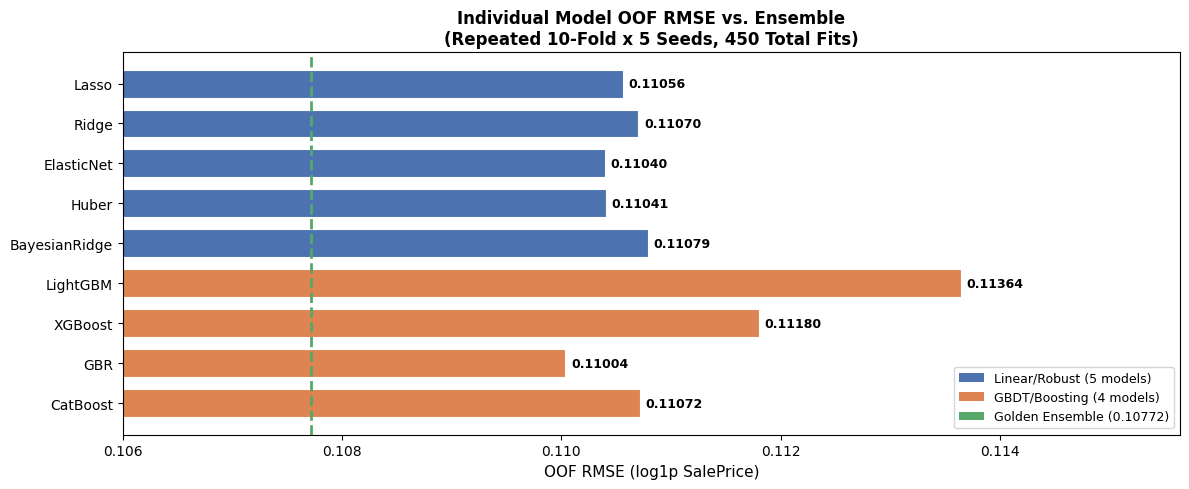

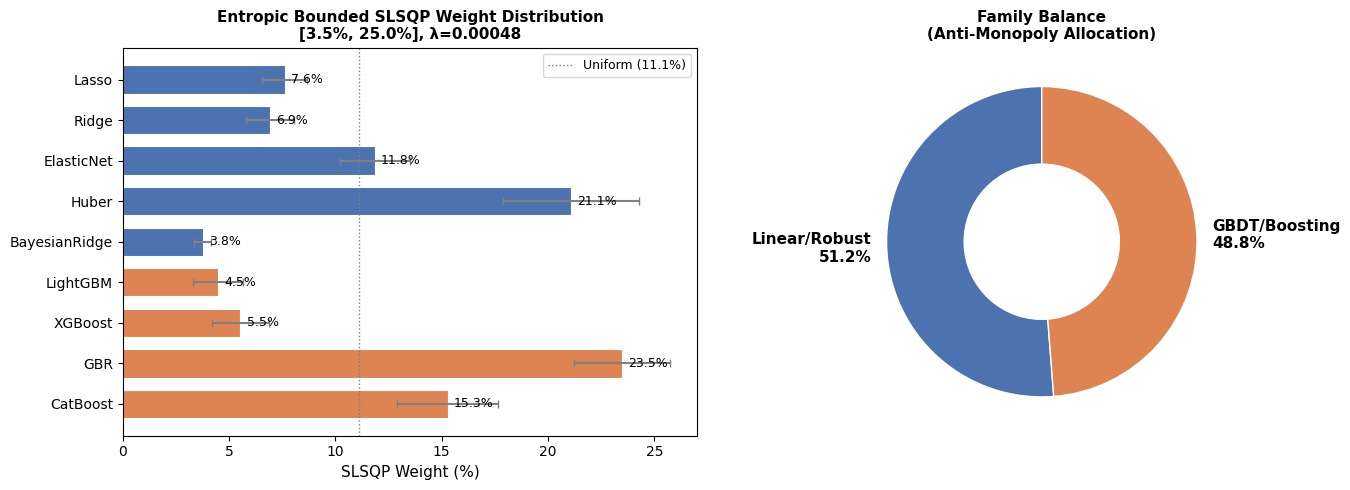

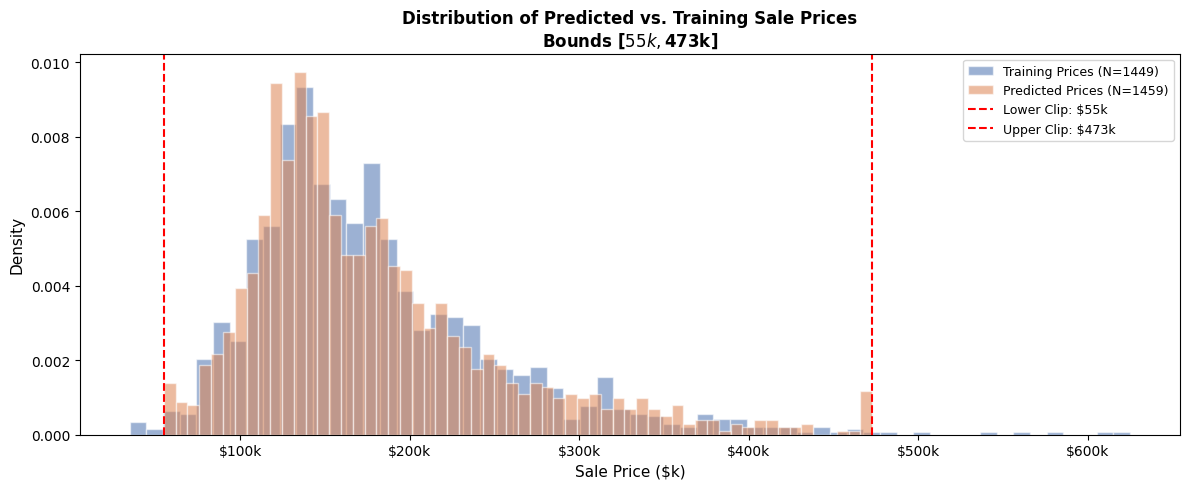

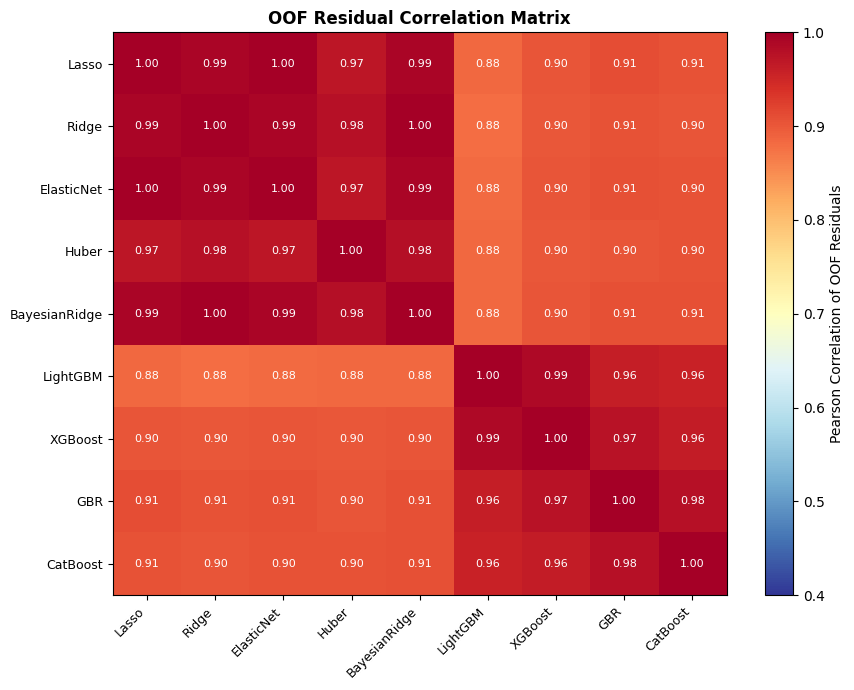

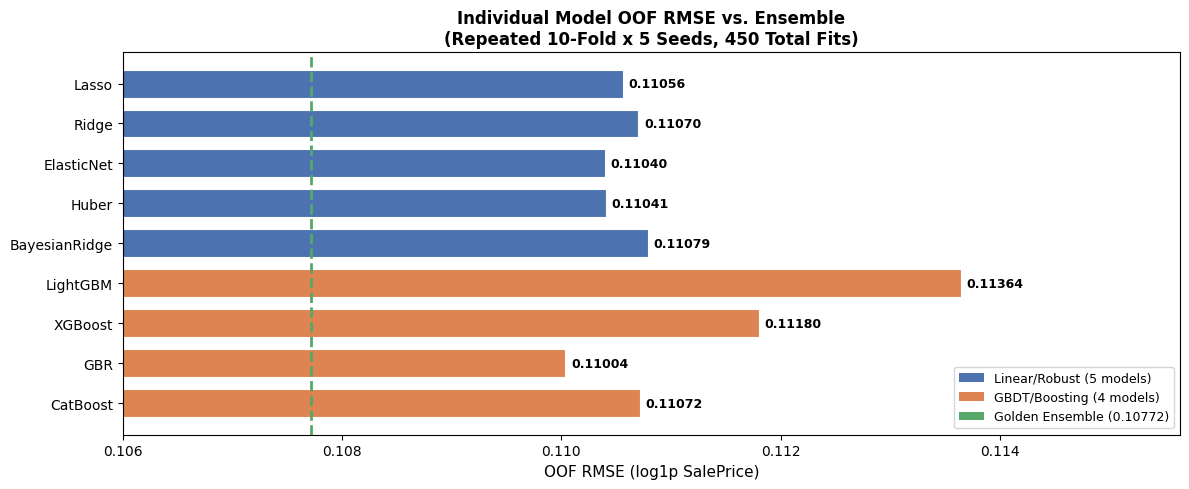

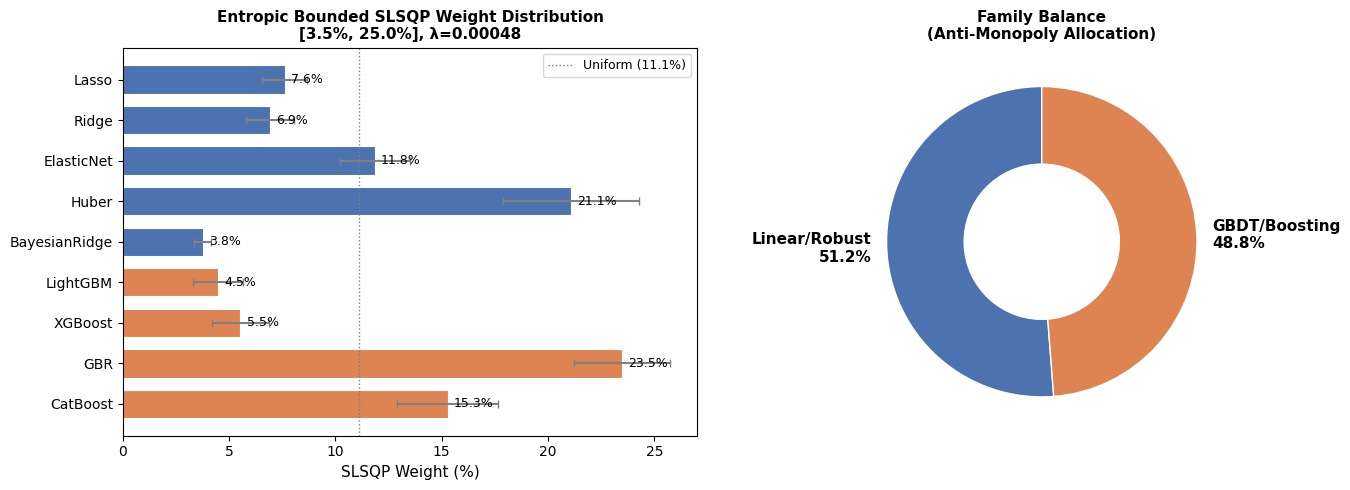

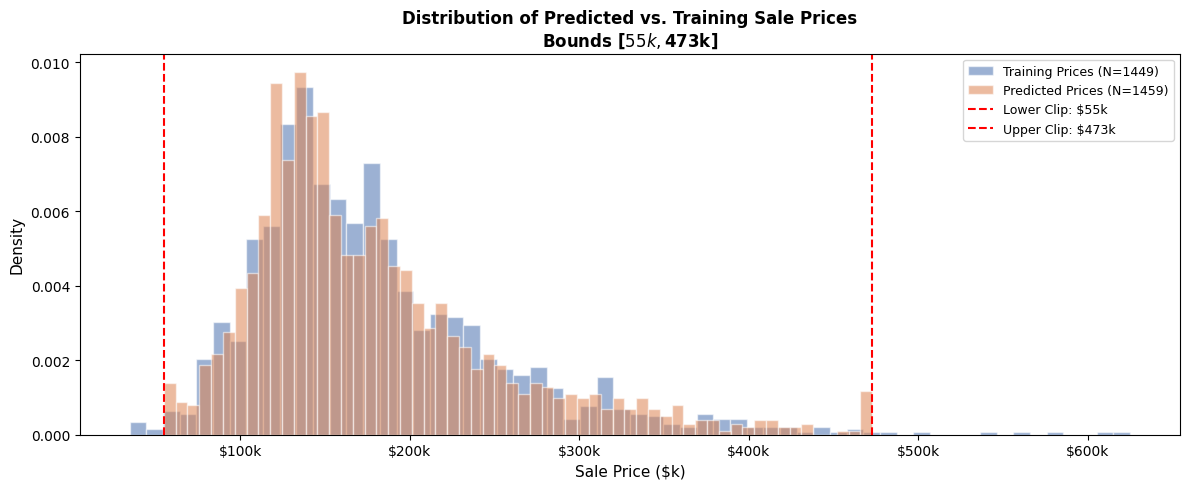

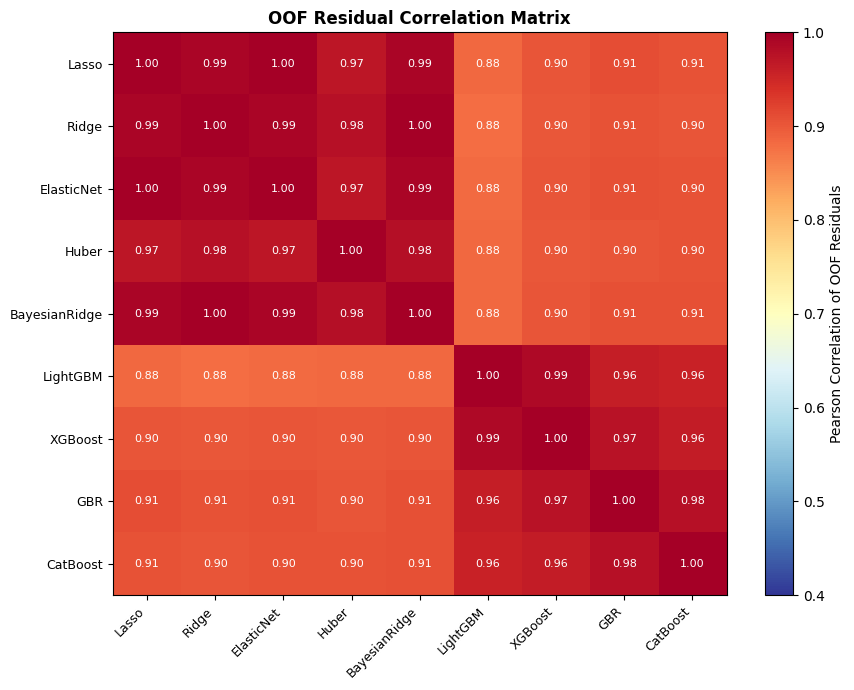

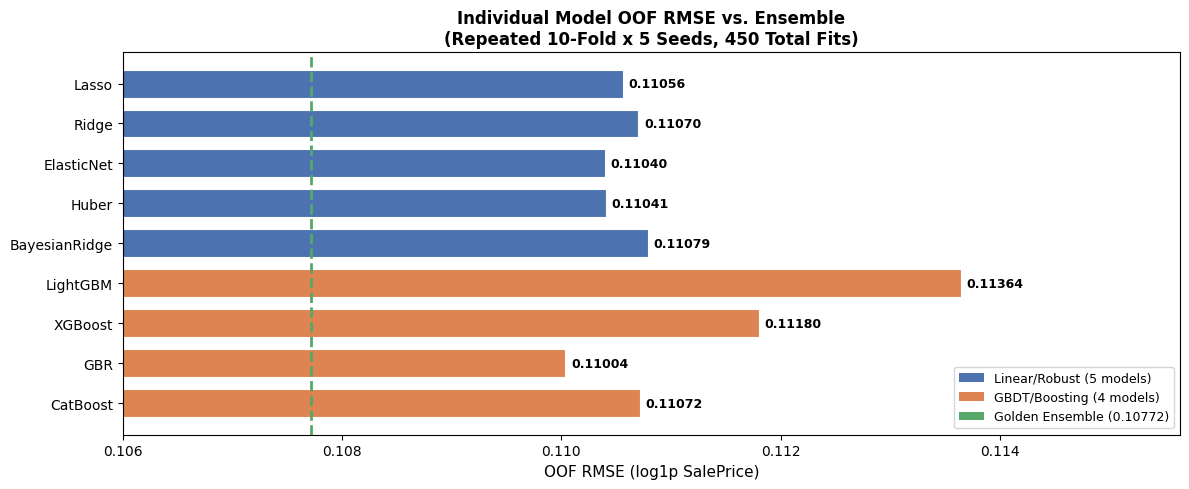

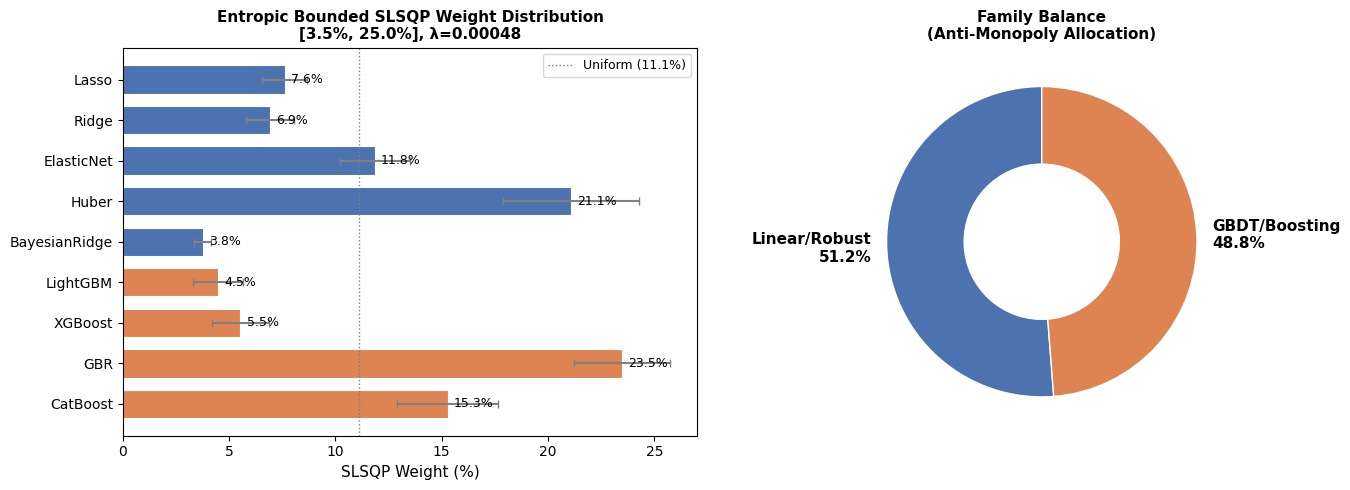

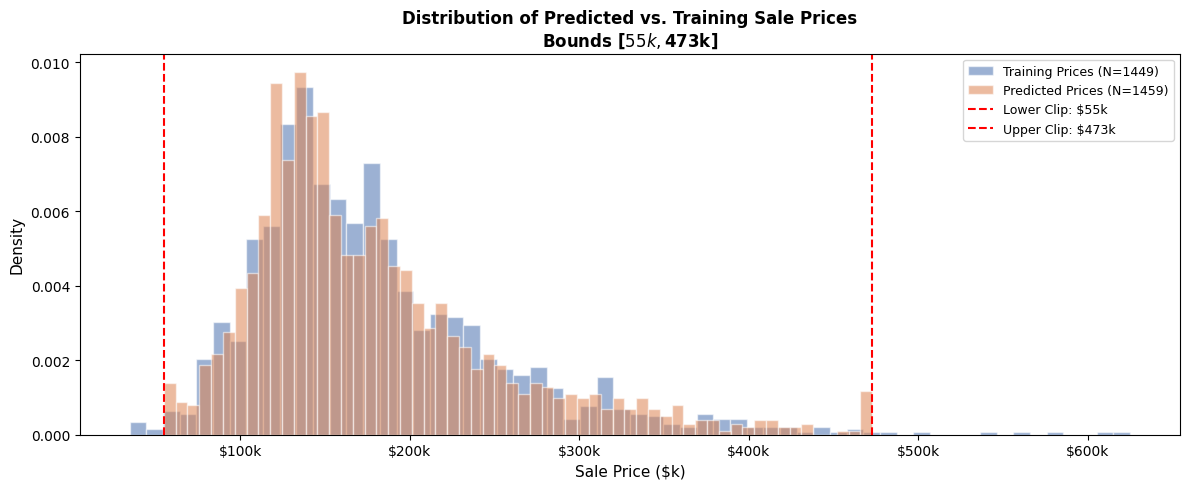

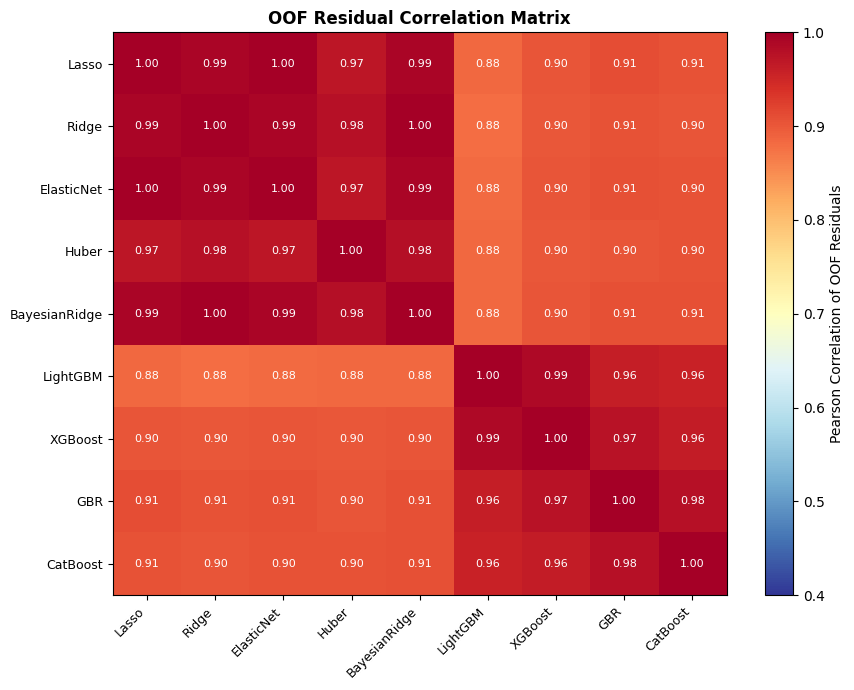

In [28]:
timer.phase("CELL 11: Publication-Quality Visualizations")

if not HAS_MATPLOTLIB:
    timer.log("WARNING: matplotlib not available. Skipping visualizations.")
else:
    import matplotlib.ticker as mticker
    from matplotlib.patches import Patch

    COLORS_LINEAR = '#4C72B0'    # Steel blue for linear models
    COLORS_TREE = '#DD8452'      # Orange for tree models
    COLORS_ENSEMBLE = '#55A868'  # Green for ensemble
    
    linear_names_set = {'Lasso', 'Ridge', 'ElasticNet', 'Huber', 'BayesianRidge'}
    
    model_colors = [
        COLORS_LINEAR if m in linear_names_set else COLORS_TREE
        for m in model_keys
    ]

    # ─── Figure 1: OOF RMSE by Base Model ───────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(12, 5))
    scores = [individual_scores[m] for m in model_keys]
    bars = ax1.barh(model_keys, scores, color=model_colors, edgecolor='white',
                    linewidth=0.8, height=0.7)
    
    ax1.axvline(x=cv_blend, color=COLORS_ENSEMBLE, linestyle='--', linewidth=2,
                label=f'Ensemble CV: {cv_blend:.5f}')
    
    for bar, score in zip(bars, scores):
        ax1.text(bar.get_width() + 0.00005, bar.get_y() + bar.get_height()/2,
                 f'{score:.5f}', va='center', fontsize=9, fontweight='bold')
    
    ax1.set_xlabel('OOF RMSE (log1p SalePrice)', fontsize=11)
    ax1.set_title(f'Individual Model OOF RMSE vs. Ensemble\n(Repeated {N_SPLITS}-Fold x {N_SEEDS} Seeds, {TOTAL_MODELS} Total Fits)',
                  fontsize=12, fontweight='bold')
    ax1.set_xlim(0.106, max(scores) + 0.002)
    ax1.invert_yaxis()
    
    legend_elements = [
        Patch(facecolor=COLORS_LINEAR, label='Linear/Robust (5 models)'),
        Patch(facecolor=COLORS_TREE, label='GBDT/Boosting (4 models)'),
        Patch(facecolor=COLORS_ENSEMBLE, label=f'Golden Ensemble ({cv_blend:.5f})')
    ]
    ax1.legend(handles=legend_elements, fontsize=9, loc='lower right')
    
    plt.tight_layout()
    plt.savefig('fig1_oof_rmse_models.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ─── Figure 2: SLSQP Weight Distribution ────────────────────────────────
    fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(14, 5))
    
    bars2 = ax2a.barh(model_keys, avg_weights * 100, color=model_colors,
                      edgecolor='white', linewidth=0.8, height=0.7,
                      xerr=std_weights * 100, capsize=3, ecolor='gray')
    
    ax2a.axvline(x=100/n_models, color='gray', linestyle=':', linewidth=1,
                 label=f'Uniform ({100/n_models:.1f}%)')
    ax2a.set_xlabel('SLSQP Weight (%)', fontsize=11)
    ax2a.set_title(f'Entropic Bounded SLSQP Weight Distribution\n[{WEIGHT_LOWER*100:.1f}%, {WEIGHT_UPPER*100:.1f}%], λ={ENTROPY_LAMBDA}',
                   fontsize=11, fontweight='bold')
    ax2a.legend(fontsize=9)
    ax2a.invert_yaxis()
    
    for bar, w in zip(bars2, avg_weights):
        ax2a.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                  f'{w*100:.1f}%', va='center', fontsize=9)
    
    family_data = [linear_total * 100, tree_total * 100]
    family_labels = [f'Linear/Robust\n{linear_total*100:.1f}%',
                     f'GBDT/Boosting\n{tree_total*100:.1f}%']
    
    ax2b.pie(
        family_data, labels=family_labels, colors=[COLORS_LINEAR, COLORS_TREE],
        startangle=90, wedgeprops=dict(width=0.5, edgecolor='white'),
        textprops=dict(fontsize=11, fontweight='bold')
    )
    ax2b.set_title('Family Balance\n(Anti-Monopoly Allocation)', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('fig2_slsqp_weights.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ─── Figure 3: Price Distribution ───────────────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(12, 5))
    
    ax3.hist(train_prices / 1000, bins=60, alpha=0.55, color=COLORS_LINEAR,
             label=f'Training Prices (N={ntrain})', edgecolor='white', density=True)
    ax3.hist(final_pred / 1000, bins=60, alpha=0.55, color=COLORS_TREE,
             label=f'Predicted Prices (N={ntest})', edgecolor='white', density=True)
    
    ax3.axvline(x=LOW_CLIP / 1000, color='red', linestyle='--', linewidth=1.5,
                label=f'Lower Clip: ${LOW_CLIP/1000:.0f}k')
    ax3.axvline(x=HIGH_CLIP / 1000, color='red', linestyle='--', linewidth=1.5,
                label=f'Upper Clip: ${HIGH_CLIP/1000:.0f}k')
    
    ax3.set_xlabel('Sale Price ($k)', fontsize=11)
    ax3.set_ylabel('Density', fontsize=11)
    ax3.set_title(f'Distribution of Predicted vs. Training Sale Prices\nBounds [${LOW_CLIP/1000:.0f}k, ${HIGH_CLIP/1000:.0f}k]',
                  fontsize=12, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
    
    plt.tight_layout()
    plt.savefig('fig3_price_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ─── Figure 4: OOF Residual Correlation Matrix ───────────────────────────
    fig4, ax4 = plt.subplots(figsize=(9, 7))
    
    residuals = {name: oof_predictions[name] - y_values for name in model_keys}
    res_df = pd.DataFrame(residuals)
    corr = res_df.corr()
    
    im = ax4.imshow(corr.values, cmap='RdYlBu_r', vmin=0.4, vmax=1.0, aspect='auto')
    
    ax4.set_xticks(range(len(model_keys)))
    ax4.set_yticks(range(len(model_keys)))
    ax4.set_xticklabels(model_keys, rotation=45, ha='right', fontsize=9)
    ax4.set_yticklabels(model_keys, fontsize=9)
    
    for i in range(len(model_keys)):
        for j in range(len(model_keys)):
            val = corr.values[i, j]
            color = 'white' if val > 0.85 else 'black'
            ax4.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)
    
    plt.colorbar(im, ax=ax4, label='Pearson Correlation of OOF Residuals')
    ax4.set_title('OOF Residual Correlation Matrix', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('fig4_residual_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()

In [26]:
from IPython.display import FileLink
FileLink('submission.csv')

/kaggle/working/submission.csv